In [2]:
import numpy as np
import pandas as pd
import scipy.stats
from sklearn import linear_model
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Solutions for Homework 1, Part 2

Questions 1 and 2 are worth one point each. The remainder are worth two points each.

# Q1

In [3]:
data = pd.read_csv("data.csv")

In [3]:
data.head()

,PERMNO,date,TICKER,COMNAM,CUSIP,BIDLO,ASKHI,PRC,BID,ASK,SHROUT,CFACPR
0,84415,20000929,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,7.8750,9.125,8.3125,8.0625,8.4375,7000,0.25
1,84415,20001031,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,5.6250,8.375,5.6250,5.5000,6.0625,7000,0.25
2,84415,20001130,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,5.8750,7.750,7.5000,7.2500,7.5000,7000,0.25
3,84415,20001229,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,7.0625,8.500,7.2500,6.7500,7.1875,7000,0.25
4,84415,20010131,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,6.8750,8.375,8.1250,8.0625,8.1875,7000,0.25


In [4]:
data.shape

(356, 12)

There are 356 rows (stock-day combinations) and 12 columns.

# Q2

In [4]:
set(data['TICKER'])

{'BBY', 'BPHX', 'CRYS', 'MDSY'}

In [5]:
set(data['CUSIP'])

{'08651610', 'M7037810'}

There are 4 distinct tickers but only 2 distinct CUSIP IDs, because the ticker symbol for a stock can change over time.

# Q3

In [6]:
data[data['CUSIP'] == 'M7037810'].iloc[30:40]

,PERMNO,date,TICKER,COMNAM,CUSIP,BIDLO,ASKHI,PRC,BID,ASK,SHROUT,CFACPR
30,84415,20030331,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,-2.160,2.41,2.300,2.18,2.30,13449,0.25
31,84415,20030430,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,2.180,2.55,-2.445,2.41,2.48,13449,0.25
32,84415,20030530,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,-2.445,2.70,2.510,2.50,2.70,13449,0.25
33,84415,20030630,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,2.640,3.25,-3.075,3.05,3.10,13449,0.25
34,84415,20030731,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,3.050,3.70,3.510,3.51,3.70,13449,0.25
35,84415,20030829,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,3.310,3.69,3.540,3.37,3.54,13449,0.25
36,84415,20030930,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,3.431,4.00,3.750,3.75,3.84,13449,0.25
37,84415,20031031,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,3.750,4.55,4.250,4.25,4.54,13449,0.25
38,84415,20031128,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,4.250,5.50,5.030,4.86,5.03,13449,0.25
39,84415,20031231,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,5.200,7.04,5.900,5.96,5.99,13484,0.25


We see that the ticker symbol changed the same month that the company changed its name. We confirm this with a google search: https://www.businesswire.com/news/home/20030810005010/en/Crystal-Systems-Solutions-New-Corporate-BluePhoenix-Solutions

# Q4

In [7]:
set(data['CFACPR'])

{0.25, 1.0, 1.5, 2.25}

There are 4 values for CFACPR in the dataset.

In [8]:
data[data['CFACPR'].isna()]

,PERMNO,date,TICKER,COMNAM,CUSIP,BIDLO,ASKHI,PRC,BID,ASK,SHROUT,CFACPR


There are no missing values for CFACPR.

In [9]:
data['PRCadj'] = data['PRC'] / data['CFACPR']

In [10]:
data[data['CFACPR'] == 1.5].iloc[0]

PERMNO                   85914
date                  20020531
TICKER                     BBY
COMNAM    BEST BUY COMPANY INC
CUSIP                 08651610
BIDLO                    45.05
ASKHI                     74.8
PRC                       46.2
BID                      46.07
ASK                      46.28
SHROUT                  318694
CFACPR                     1.5
PRCadj                    30.8
Name: 198, dtype: object

In May 2002, the price of Best Buy was $\$$46.20 but there was an adjustment factor of 1.5, so the adjusted price was $\$$30.80.

# Q5

In [11]:
data[data['PRCadj'].isna()]

,PERMNO,date,TICKER,COMNAM,CUSIP,BIDLO,ASKHI,PRC,BID,ASK,SHROUT,CFACPR,PRCadj


There are no "not available" adjusted prices.

# Q6

In [12]:
len(set(data['date']))

178

There are 178 unique dates in the dataset.

# Q7

In [13]:
data[data['PRC'] < 0]

,PERMNO,date,TICKER,COMNAM,CUSIP,BIDLO,ASKHI,PRC,BID,ASK,SHROUT,CFACPR,PRCadj
19,84415,20020430,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,3.4100,4.00,-3.585,3.40,3.77,10018,0.25,-14.340
29,84415,20030228,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,2.1000,2.30,-2.165,2.13,2.20,13449,0.25,-8.660
31,84415,20030430,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,2.1800,2.55,-2.445,2.41,2.48,13449,0.25,-9.780
33,84415,20030630,CRYS,CRYSTAL SYSTEMS SOLUTIONS,M7037810,2.6400,3.25,-3.075,3.05,3.10,13449,0.25,-12.300
58,84415,20050729,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,3.8500,4.25,-4.050,4.00,4.10,13556,0.25,-16.200
71,84415,20060831,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,4.6000,5.70,-5.500,5.45,5.55,13560,0.25,-22.000
164,84415,20140530,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,4.1000,4.30,-4.100,4.05,4.15,11468,1.00,-4.100
168,84415,20140930,BPHX,BLUEPHOENIX SOLUTIONS LTD,M7037810,3.5501,3.81,-3.595,3.50,3.69,11621,1.00,-3.595
172,84415,20150130,MDSY,MODSYS INTERNATIONAL LTD,M7037810,3.0500,3.46,-3.075,2.95,3.20,17844,1.00,-3.075
175,84415,20150430,MDSY,MODSYS INTERNATIONAL LTD,M7037810,2.2601,3.10,-2.620,2.29,2.95,17897,1.00,-2.620


Negative prices in the CRSP dataset indicate that the closing price was missing for that date, so instead the average of the bid and ask prices were used. We note that by inspecting the volume data that these stocks were quite lightly traded during these months.

In [15]:
data.loc[data['PRC'] < 0, 'PRC'] =  -data[data['PRC'] < 0]['PRC']
data.loc[data['PRCadj'] < 0, 'PRCadj'] =  -data[data['PRCadj'] < 0]['PRCadj']

In [17]:
data[data['PRC'] < 0]

,PERMNO,date,TICKER,COMNAM,CUSIP,BIDLO,ASKHI,PRC,BID,ASK,SHROUT,CFACPR,PRCadj


# Q8

In [17]:
data[data['BID'] > data['ASK']]

,PERMNO,date,TICKER,COMNAM,CUSIP,BIDLO,ASKHI,PRC,BID,ASK,SHROUT,CFACPR,PRCadj
252,85914,20061130,BBY,BEST BUY COMPANY INC,08651610,51.39,55.84,54.97,54.92,54.91,480250,1.0,54.97


In Nov 2006, the bid price of Best Buy was higher than the ask. This could be a data error, or the closing bid entered at the last minute and the market closed before any trade was able to be resolved. Instances of a so-called **crossed market** can happen in times of rapid trading. See https://www.investopedia.com/terms/c/crossedmarket.asp.

# Q9


In [18]:
bby = data.loc[data['CUSIP'] == '08651610'].copy()
modsys = data.loc[data['CUSIP'] == 'M7037810'].copy()

In [19]:
bby['momentum'] = bby['PRCadj'].shift(1) / bby['PRCadj'].shift(4) - 1
modsys['momentum'] = modsys['PRCadj'].shift(1) / modsys['PRCadj'].shift(4) - 1

# Q10

In [19]:
bby['PRCinc'] = bby['PRCadj'].shift(-1) > bby['PRCadj']
bby['PRCdec'] = bby['PRCadj'].shift(-1) < bby['PRCadj']
modsys['PRCinc'] = modsys['PRCadj'].shift(-1) > modsys['PRCadj']
modsys['PRCdec'] = modsys['PRCadj'].shift(-1) < modsys['PRCadj']

/Users/chadschafer/anaconda3/lib/python3.7/site-packages/numpy/lib/histograms.py:824: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/Users/chadschafer/anaconda3/lib/python3.7/site-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


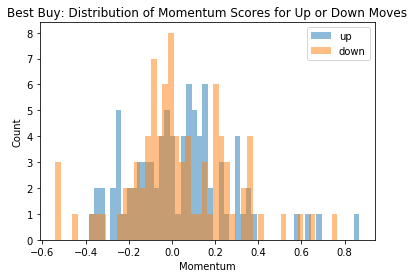

In [20]:
plt.hist(bby[bby['PRCinc'] == 1]['momentum'], bins=50, alpha=0.5, label="up")
plt.hist(bby[bby['PRCdec'] == 1]['momentum'], bins=50, alpha=0.5, label="down")
plt.legend(loc='upper right')
plt.title("Best Buy: Distribution of Momentum Scores for Up or Down Moves")
plt.xlabel("Momentum")
plt.ylabel("Count")
plt.show()

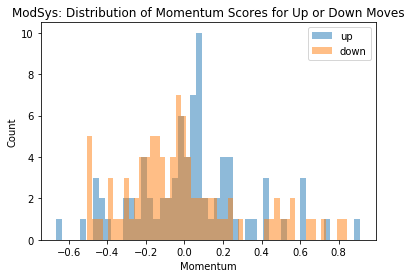

In [21]:
plt.hist(modsys[modsys['PRCinc'] == 1]['momentum'], bins=50, alpha=0.5, label="up")
plt.hist(modsys[modsys['PRCdec'] == 1]['momentum'], bins=50, alpha=0.5, label="down")
plt.legend(loc='upper right')
plt.title("ModSys: Distribution of Momentum Scores for Up or Down Moves")
plt.xlabel("Momentum")
plt.ylabel("Count")
plt.show()

The distribution of momentum scores is slightly more positive (shifted to the right) when the next month return is positive, as compared to the distribution of momentum scores when the next month return is negative.